# Credit Card Fraud Detection — Exploratory Data Analysis & Preprocessing

**Project**: Contextual Bandits vs. Supervised Learning for Credit Card Fraud Detection
**Dataset**: [ULB Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

This notebook has two jobs:
1. **Explore** the raw dataset to confirm its structure, class imbalance, and
   a couple of properties that directly informed later design decisions
   (e.g. the train/test split ratio and why `Amount` needs transforming).
2. **Apply fixed, split-independent preprocessing** and export the result to
   `creditcard_preprocessed.csv`.

> **Important scope note**: this notebook only applies transforms that are
> *deterministic and don't depend on the train/test split* (log-transforming
> `Amount`, deriving time-of-day features from `Time`). The final z-score
> **standardization** of features is deliberately **NOT** done here — it must
> be fit on the training region only (to avoid leaking test-set statistics
> into training) and is applied later, at run-time, in `Common/preprocessing.py`.

## 1. Load the raw dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("creditcard.csv")

print("Shape:", df.shape)
print()
print("Data types:")
print(df.dtypes.value_counts())
print()
print("Missing values:", df.isnull().sum().sum())


Shape: (284807, 31)

Data types:
float64    30
int64       1
Name: count, dtype: int64

Missing values: 0


In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Class distribution (fraud vs. legit)

This dataset is famous for extreme class imbalance.
Worth confirming the exact numbers rather than assuming, since this directly shapes
every later modeling decision (cost-sensitive rewards, imbalance-aware classifier weighting, AUPRC over ROC-AUC, etc.).

Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


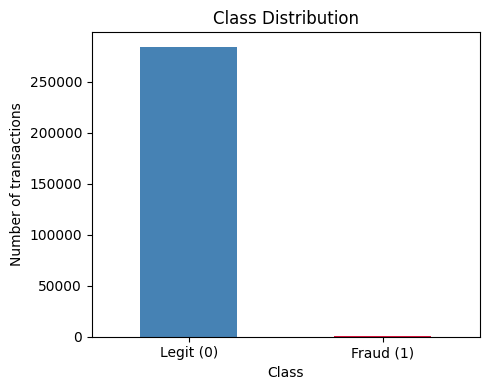

In [7]:
class_counts = df["Class"].value_counts()
fraud_rate = df["Class"].mean() * 100

print(class_counts)
print(f"\nFraud rate: {fraud_rate:.4f}%")

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind="bar", ax=ax, color=["steelblue", "crimson"])
ax.set_xticklabels(["Legit (0)", "Fraud (1)"], rotation=0)
ax.set_ylabel("Number of transactions")
ax.set_title(f"Class Distribution")
plt.tight_layout()
plt.show()


## 3. Time coverage

`Time` is **seconds elapsed since the first transaction** in the dataset —
not a time-of-day field. 
Confirming the exact span here matters because it
tells us how many day/night cycles we actually have (relevant to whether
cyclic time-of-day encoding is even meaningful) and anchors the chronological
train/test split used later.

In [8]:
print("Time range (seconds):", df["Time"].min(), "-", df["Time"].max())
print("Span (hours):", (df["Time"].max() - df["Time"].min()) / 3600)
# -> ~48 hours: exactly 2 daily cycles. Enough to justify deriving a
#    hour-of-day feature, but too short to expect a bandit/classifier to
#    learn robust weekly seasonality patterns.

Time range (seconds): 0.0 - 172792.0
Span (hours): 47.99777777777778


## 4. Amount distribution — why it needs transforming

`Amount` is heavily right-skewed: most transactions are small, with a long
tail of rare, very large transactions. This matters a lot for any *linear*
model (Logistic Regression, LinUCB, LinTS) — a raw, unscaled, skewed feature
like this can dominate or destabilize a linear fit.

Overall Amount stats:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Amount stats by class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


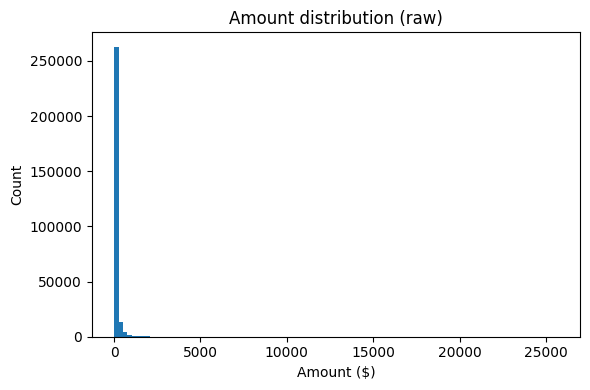

In [10]:
print("Overall Amount stats:")
print(df["Amount"].describe())
print()
print("Amount stats by class:")
print(df.groupby("Class")["Amount"].describe())

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["Amount"], bins=100)
ax.set_title("Amount distribution (raw)")
ax.set_xlabel("Amount ($)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 5. Fraud rate over time — a non-stationarity check

Before committing to a chronological (rather than random) train/test split,
it's worth checking whether fraud is roughly evenly distributed over time,
or whether it clusters. 

In [11]:
df_sorted = df.sort_values("Time").reset_index(drop=True)
n = len(df_sorted)

first60 = df_sorted.iloc[:int(n * 0.6)]
last40 = df_sorted.iloc[int(n * 0.6):]

print(f"Fraud rate, first 60% of transactions (chronological): {first60['Class'].mean()*100:.4f}%")
print(f"Fraud rate, last 40% of transactions (chronological):  {last40['Class'].mean()*100:.4f}%")
# Fraud rate is noticeably higher earlier in the window than later --
# a mild non-stationarity worth a mention in the final report's
# limitations section, even though it's out of scope for this project's
# chosen research gaps (4a, 4c).


Fraud rate, first 60% of transactions (chronological): 0.2107%
Fraud rate, last 40% of transactions (chronological):  0.1159%


## 6. Preprocessing Step 1 — `log1p(Amount)`

Fixes the *shape* of the Amount distribution (not just its scale) by
compressing the long right tail, which is what actually helps a linear
model fit a stable slope across both small and large transactions.

**Important**: this engineered `log_amount` column is for use as a *model
input feature* only. The original, untransformed `Amount` column is
**kept in the export** — it's still needed downstream for the cost-sensitive
reward function (`-Amount` for a missed fraud), which must stay in real
dollars, not log-space.

              Amount     log_amount
count  284807.000000  284807.000000
mean       88.349619       3.152188
std       250.120109       1.656648
min         0.000000       0.000000
25%         5.600000       1.887070
50%        22.000000       3.135494
75%        77.165000       4.358822
max     25691.160000      10.153941


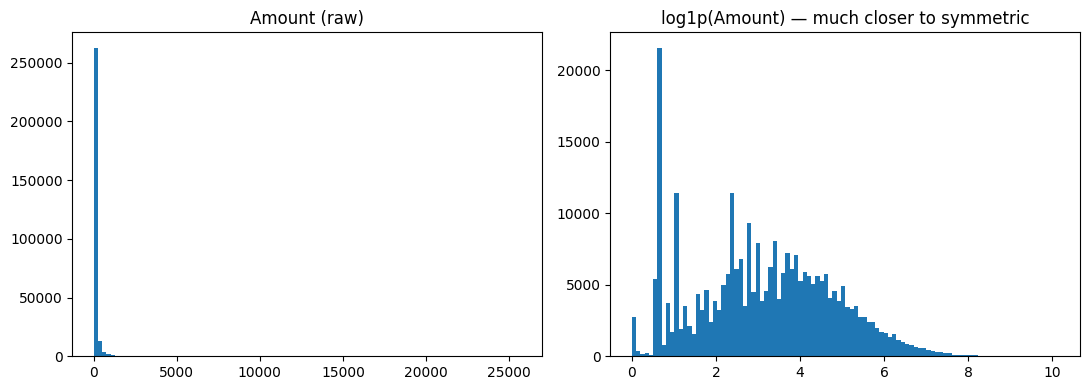

In [12]:
df["log_amount"] = np.log1p(df["Amount"])

print(df[["Amount", "log_amount"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["Amount"], bins=100)
axes[0].set_title("Amount (raw)")
axes[1].hist(df["log_amount"], bins=100)
axes[1].set_title("log1p(Amount) — much closer to symmetric")
plt.tight_layout()
plt.show()


## 7. Preprocessing Step 2 — `hour_of_day` + cyclic encoding

`Time` itself (raw elapsed seconds, 0 to ~172,792) is **not** fed to models
directly — it has no meaningful linear relationship with fraud (transaction
#150,000 isn't "more fraud-like" than #10,000 just because the counter is
bigger). Instead we derive **hour of day** (`Time mod 86400`, in hours) and
cyclically encode *that*, so that e.g. 23:59 and 00:01 are correctly treated
as close together rather than maximally far apart.

   Time  hour_of_day  hour_sin  hour_cos
0   0.0     0.000000  0.000000       1.0
1   0.0     0.000000  0.000000       1.0
2   1.0     0.000278  0.000073       1.0
3   1.0     0.000278  0.000073       1.0
4   2.0     0.000556  0.000145       1.0


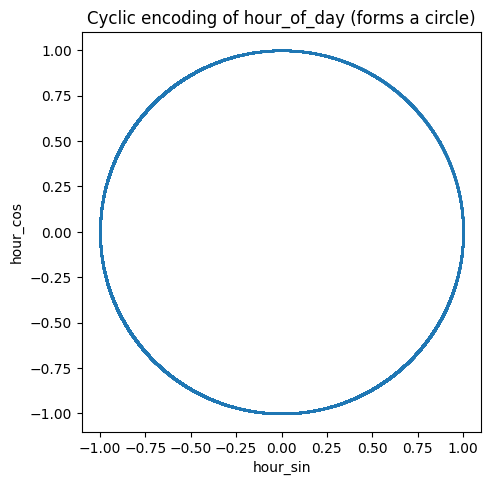

In [13]:
df["hour_of_day"] = (df["Time"] % 86400) / 3600.0
df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)

print(df[["Time", "hour_of_day", "hour_sin", "hour_cos"]].head())

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(df["hour_sin"], df["hour_cos"], s=1, alpha=0.1)
ax.set_title("Cyclic encoding of hour_of_day (forms a circle)")
ax.set_xlabel("hour_sin")
ax.set_ylabel("hour_cos")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


## 8. Assemble final export

Columns kept in `creditcard_preprocessed.csv`:

| Column(s) | Purpose |
|---|---|
| `Time` | kept for chronological sorting / train-test split downstream |
| `V1`–`V28` | raw PCA'd features, unscaled (standardization deferred to run-time) |
| `Amount` | **raw dollars** — required by the cost-sensitive reward function |
| `log_amount` | engineered context feature for linear models |
| `hour_of_day`, `hour_sin`, `hour_cos` | engineered time-of-day context features |
| `Class` | label (0 = legit, 1 = fraud) |

Deliberately **not** included: any standardized/z-scored version of these
features — that must be fit on the training split only, and happens later
in `Common/preprocessing.py`, not here.

In [14]:
v_cols = [c for c in df.columns if c.startswith("V")]
export_cols = (
    ["Time"] + v_cols + ["Amount", "log_amount", "hour_of_day", "hour_sin", "hour_cos", "Class"]
)
df_export = df[export_cols]

df_export.to_csv("creditcard_preprocessed.csv", index=False)

print("Exported shape:", df_export.shape)
print("Exported columns:", list(df_export.columns))


Exported shape: (284807, 35)
Exported columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'log_amount', 'hour_of_day', 'hour_sin', 'hour_cos', 'Class']


## Summary

- Confirmed: 284,807 transactions, 492 fraud (0.173%), spanning ~48 hours, no missing values.
- Confirmed: fraud rate is higher in the earlier part of the stream than the later part
  (mild non-stationarity — noted as a limitation, out of scope for the current research gaps).
- Applied `log1p(Amount)` to fix distributional skew for linear models.
- Derived `hour_of_day` and its cyclic (`sin`/`cos`) encoding from raw `Time`.
- Exported `creditcard_preprocessed.csv` with both raw and engineered columns,
  deliberately leaving train-fit standardization for later, in `Common/preprocessing.py`.